## 1. What this notebook computes

Curvature is the central idea of this chapter, and it is easiest to understand on
surfaces that we can picture. This notebook applies exactly the formulas that
Notebook 03b applies to the author's 8-dimensional metric to two 2-dimensional
surfaces:

- the **flat plane in polar coordinates** $(r, \varphi)$: its Christoffel symbols are
  not zero, yet its Riemann tensor is zero: Christoffel symbols describe the
  coordinates, the Riemann tensor describes the space;
- a **sphere of radius** $a$ in the coordinates $(\theta, \varphi)$ (angle from the
  north pole, angle around the axis): its curvature is $1/a^2$, its Ricci scalar
  $2/a^2$, its Kretschmann scalar $4/a^4$.

Then it shows what curvature does, with numerical integrations (the Runge-Kutta
method RK4):

- a vector carried around a circle of latitude **without turning** (parallel
  transport) comes back turned, by an angle equal to the enclosed area divided by
  $a^2$;
- the straightest curves of the sphere (**geodesics**) are great circles;
- two geodesics that start **parallel** approach each other and meet, at the rate
  that the curvature predicts.

It draws 5 figures and prints a PASS line for every check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 03c (Curvature from zero: the plane, the sphere, parallel transport and
geodesics) is the file `Revision/textbook/notebooks/03c_sphere_curvature.ipynb` of the
repository Dirac_claude. It applies the formulas of the Christoffel symbols, the Riemann
tensor, the Ricci tensor and the Ricci and Kretschmann scalars to two surfaces that can
be pictured, the flat plane in polar coordinates and a sphere of radius a; it shows that
the plane has zero curvature although its Christoffel symbols are not zero, computes the
curvature 1/a^2 of the sphere, carries a vector around a circle of latitude by parallel
transport (a numerical integration with the Runge-Kutta method) and finds the turning
angle equal to the enclosed area divided by a^2, integrates geodesics and shows that they
are great circles, and shows that initially parallel geodesics approach each other as the
curvature predicts. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy,
sympy and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 03c_sphere_curvature.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 03c_sphere_curvature.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
03c_sphere_curvature.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:
`Revision/textbook/figures/03c.captions.json`,
`Revision/textbook/figures/03c_1_plane_polar_components.png`,
`Revision/textbook/figures/03c_2_parallel_transport_sphere.png`,
`Revision/textbook/figures/03c_3_turning_angle.png`,
`Revision/textbook/figures/03c_4_geodesics_sphere.png` and
`Revision/textbook/figures/03c_5_geodesic_deviation.png`. It changes no other file of the
repository; running it headless or saving it in JupyterLab also rewrites the notebook
file itself. It does not use the internet while it runs. The files it writes are the same
files that are stored in the repository (on another computer a figure may differ in a few
bytes, which is harmless). To get the stored versions back, run this command in the
repository folder (it also undoes every change you made yourself in the folder
Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all five figure files exist
    ALL 16 CHECKS PASSED (notebook 03c)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/03c_sphere_curvature.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 03c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 03c (Curvature from zero: the plane, the sphere, parallel transport and
# geodesics) is the file Revision/textbook/notebooks/03c_sphere_curvature.ipynb of the
# repository Dirac_claude. It applies the formulas of the Christoffel symbols, the
# Riemann tensor, the Ricci tensor and the Ricci and Kretschmann scalars to two surfaces
# that can be pictured, the flat plane in polar coordinates and a sphere of radius a; it
# shows that the plane has zero curvature although its Christoffel symbols are not zero,
# computes the curvature 1/a^2 of the sphere, carries a vector around a circle of
# latitude by parallel transport (a numerical integration with the Runge-Kutta method)
# and finds the turning angle equal to the enclosed area divided by a^2, integrates
# geodesics and shows that they are great circles, and shows that initially parallel
# geodesics approach each other as the curvature predicts. It needs a computer with
# Windows 11, macOS or Linux, an internet connection for the installation, the program
# Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
# packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
# 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
# nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
# packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 03c_sphere_curvature.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 03c_sphere_curvature.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 03c_sphere_curvature.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
# Revision/textbook/figures/03c.captions.json,
# Revision/textbook/figures/03c_1_plane_polar_components.png,
# Revision/textbook/figures/03c_2_parallel_transport_sphere.png,
# Revision/textbook/figures/03c_3_turning_angle.png,
# Revision/textbook/figures/03c_4_geodesics_sphere.png and
# Revision/textbook/figures/03c_5_geodesic_deviation.png. It changes no other file of the
# repository; running it headless or saving it in JupyterLab also rewrites the notebook
# file itself. It does not use the internet while it runs. The files it writes are the
# same files that are stored in the repository (on another computer a figure may differ
# in a few bytes, which is harmless). To get the stored versions back, run this command
# in the repository folder (it also undoes every change you made yourself in the folder
# Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all five figure files exist
#     ALL 16 CHECKS PASSED (notebook 03c)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/03c_sphere_curvature.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "03c"  # this notebook: chapter 03, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 03c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates**: numbers that name the points of a space. **Polar coordinates**
  of the plane: the distance $r$ from the origin and the angle $\varphi$ from the
  horizontal axis; $x = r\cos\varphi$, $y = r\sin\varphi$.
- **Coordinates on the sphere** of radius $a$: $\theta$ (from $0$ at the north pole
  to $\pi$ at the south pole) and $\varphi$ (around the axis); the point is
  $(a\sin\theta\cos\varphi,\ a\sin\theta\sin\varphi,\ a\cos\theta)$.
- **Metric** $g_{\mu\nu}$: the rule $ds^2 = \sum g_{\mu\nu}\,dx^\mu dx^\nu$ for the
  squared length of a small step. Plane: $ds^2 = dr^2 + r^2 d\varphi^2$. Sphere:
  $ds^2 = a^2(d\theta^2 + \sin^2\theta\, d\varphi^2)$.
- **Vector components**: a vector $V = V^r e_r + V^\varphi e_\varphi$ is written with
  the coordinate basis vectors $e_r$ (length 1) and $e_\varphi$ (length $r$).
- **Christoffel symbols** $\Gamma^a{}_{bc}$, **covariant derivative**
  $\nabla_b V^a = \partial_b V^a + \sum_c \Gamma^a{}_{bc} V^c$: the derivative of a
  vector field corrected for the turning of the coordinate basis.
- **Parallel transport** along a curve $x^a(t)$: carrying a vector so that its
  covariant derivative along the curve is zero,
  $dV^a/dt + \sum_{b,c} \Gamma^a{}_{bc}\, (dx^b/dt)\, V^c = 0$ ("not turning").
- **Geodesic**: a curve whose velocity is parallel transported along itself,
  $d^2x^a/ds^2 + \sum_{b,c}\Gamma^a{}_{bc}\,(dx^b/ds)(dx^c/ds) = 0$; the straightest
  possible curve. **Great circle**: a circle on the sphere whose centre is the
  centre of the sphere (the equator, the meridians, and all their rotations).
- **Riemann tensor** $R^a{}_{bcd}$ (the MTW convention of the Revision records),
  **Gaussian curvature** $R^{\theta\varphi}{}_{\theta\varphi}$ of a surface,
  **Ricci scalar** $R$, **Kretschmann scalar** $K$: the measures of curvature.
- **Holonomy** (turning angle): the angle by which a parallel-transported vector is
  turned after going once around a closed curve.
- **RK4**: the classical Runge-Kutta method of order 4 for solving
  $dy/dt = f(t, y)$ step by step.

## 4. The physical and mathematical situation

Two surfaces, each with two coordinates:

$$\text{plane: } g = \begin{pmatrix} 1 & 0 \\ 0 & r^2 \end{pmatrix},\qquad
\text{sphere: } g = \begin{pmatrix} a^2 & 0 \\ 0 & a^2 \sin^2\theta
\end{pmatrix}.$$

The plane is flat: on a sheet of paper a vector carried around any closed loop
without turning comes back unchanged, parallel lines stay parallel, and the angles
of a triangle add up to $\pi$. The sphere is curved: a vector carried around a loop
comes back turned, lines that start parallel meet (two meridians that cross the
equator at right angles meet at the poles), and the angles of a triangle add up to
more than $\pi$. The Riemann tensor measures exactly this. The formulas are those
used for the author's metric:

$$\Gamma^a{}_{bc} = \tfrac12 \sum_d g^{ad}(\partial_b g_{dc} + \partial_c g_{db}
- \partial_d g_{bc}),\qquad
R^a{}_{bcd} = \partial_c \Gamma^a{}_{bd} - \partial_d \Gamma^a{}_{bc}
+ \sum_e (\Gamma^a{}_{ce}\Gamma^e{}_{bd} - \Gamma^a{}_{de}\Gamma^e{}_{bc}),$$

$R^{ab}{}_{cd} = \sum_e g^{be} R^a{}_{ecd}$, $R^a{}_b = \sum_c R^{ac}{}_{bc}$,
$R = \sum_a R^a{}_a$, $K = \sum R^{ab}{}_{cd} R^{cd}{}_{ab}$. For a surface the only
independent component is the **Gaussian curvature** $R^{12}{}_{12}$; a sphere of
radius $a$ has the Gaussian curvature $1/a^2$, the same at every point.

## 5. The curvature machinery for any metric

The next cell imports the packages and defines, for a metric of any size given as a
sympy matrix, the functions `christoffel`, `riemann` (the non-zero $R^a{}_{bcd}$),
`raise_second` ($R^{ab}{}_{cd}$), `ricci` ($R^a{}_b$), and `kretschmann`. They
apply the formulas of section 4 literally, with every result simplified by sympy;
they are the same formulas that Notebook 03b applies to the author's metric.

In [2]:
import itertools  # loops over all index combinations

import numpy as np  # arrays of numbers
import sympy as sp  # exact algebra with symbols


def christoffel(metric, coordinates):
    """All Christoffel symbols table[a][b][c] of a metric."""
    n = len(coordinates)
    inverse = metric.inv()
    d_metric = [metric.diff(c) for c in coordinates]  # d_metric[c][i, j] = d_c g_ij
    table = [[[0] * n for _ in range(n)] for _ in range(n)]
    for a, b, c in itertools.product(range(n), repeat=3):
        table[a][b][c] = sp.simplify(sum(
            inverse[a, d] * (d_metric[b][d, c] + d_metric[c][d, b]
                             - d_metric[d][b, c]) for d in range(n)) / 2)
    return table


def riemann(table, coordinates):
    """The non-zero R^a_bcd (MTW convention) as a dictionary."""
    n = len(coordinates)
    result = {}
    for a, b, c, d in itertools.product(range(n), repeat=4):
        value = sp.simplify(
            sp.diff(table[a][b][d], coordinates[c])
            - sp.diff(table[a][b][c], coordinates[d])
            + sum(table[a][c][e] * table[e][b][d] - table[a][d][e] * table[e][b][c]
                  for e in range(n)))
        if value != 0:
            result[(a, b, c, d)] = value
    return result


def raise_second(riemann_table, metric):
    """The non-zero R^ab_cd = sum over e of g^(be) R^a_ecd."""
    inverse = metric.inv()
    result = {}
    for (a, e, c, d), value in riemann_table.items():
        for b in range(metric.rows):
            result[(a, b, c, d)] = result.get((a, b, c, d), 0) + inverse[b, e] * value
    return {k: sp.simplify(v) for k, v in result.items() if sp.simplify(v) != 0}


def ricci(mixed_table, n):
    """R^a_b = sum over c of R^ac_bc."""
    result = sp.zeros(n, n)
    for (a, c, b, d), value in mixed_table.items():
        if c == d:
            result[a, b] += value
    return result.applyfunc(sp.simplify)


def kretschmann(mixed_table):
    """K = sum of R^ab_cd R^cd_ab."""
    return sp.simplify(sum(v * mixed_table.get((c, d, a, b), 0)
                           for (a, b, c, d), v in mixed_table.items()))


say("Defined: christoffel, riemann, raise_second, ricci, kretschmann.")

Defined: christoffel, riemann, raise_second, ricci, kretschmann.


## 6. The flat plane in polar coordinates

With $x = r\cos\varphi$ and $y = r\sin\varphi$ a small step has
$dx = \cos\varphi\, dr - r\sin\varphi\, d\varphi$ and
$dy = \sin\varphi\, dr + r\cos\varphi\, d\varphi$; squaring and adding (the mixed
terms cancel, and $\cos^2 + \sin^2 = 1$) gives $ds^2 = dr^2 + r^2 d\varphi^2$. The
next cell computes the Christoffel symbols of this metric and its Riemann tensor.
By hand: only $g_{\varphi\varphi} = r^2$ depends on a coordinate, so
$\Gamma^r{}_{\varphi\varphi} = -\tfrac12 \partial_r r^2 = -r$ and
$\Gamma^\varphi{}_{r\varphi} = \Gamma^\varphi{}_{\varphi r} = \tfrac12 r^{-2}
\partial_r r^2 = 1/r$. The Riemann tensor must be zero, because the plane is flat.

In [3]:
r, phi = sp.symbols("r varphi", positive=True)  # polar coordinates, r > 0
plane = sp.diag(1, r ** 2)  # ds^2 = dr^2 + r^2 dphi^2
POLAR = [r, phi]
POLAR_NAMES = ["r", "phi"]
plane_gamma = christoffel(plane, POLAR)
for a, b, c in itertools.product(range(2), repeat=3):
    if plane_gamma[a][b][c] != 0:
        say(f"  Gamma^{POLAR_NAMES[a]}_({POLAR_NAMES[b]} {POLAR_NAMES[c]}) = "
            f"{plane_gamma[a][b][c]}")
check(plane_gamma[0][1][1] == -r and plane_gamma[1][0][1] == 1 / r
      and plane_gamma[1][1][0] == 1 / r,
      "plane in polar coordinates: Gamma^r_(phi phi) = -r, Gamma^phi_(r phi) = 1/r")
plane_riemann = riemann(plane_gamma, POLAR)
say(f"non-zero Riemann components of the plane: {len(plane_riemann)}")
check(plane_riemann == {},
      "the Riemann tensor of the plane is zero: the plane is flat")

  Gamma^r_(phi phi) = -r
  Gamma^phi_(r phi) = 1/r
  Gamma^phi_(phi r) = 1/r
PASS plane in polar coordinates: Gamma^r_(phi phi) = -r, Gamma^phi_(r phi) = 1/r
non-zero Riemann components of the plane: 0
PASS the Riemann tensor of the plane is zero: the plane is flat


The Christoffel symbols of the plane are not zero because the polar basis vectors
turn from point to point. Take the constant vector field $V = e_x$ (one unit to the
right everywhere). In polar components it is $V^r = \cos\varphi$,
$V^\varphi = -\sin\varphi / r$ (because $e_x = \cos\varphi\, e_r - (\sin\varphi /
r)\, e_\varphi$). These components change from point to point although the arrow
does not; the Christoffel terms of the covariant derivative must exactly cancel
their change. The next cell checks $\nabla_b V^a = \partial_b V^a + \sum_c
\Gamma^a{}_{bc} V^c = 0$ for all four combinations of $a$ and $b$.

In [4]:
V = [sp.cos(phi), -sp.sin(phi) / r]  # the constant field e_x in polar components
nabla = [[sp.simplify(sp.diff(V[a], POLAR[b])
                      + sum(plane_gamma[a][b][c] * V[c] for c in range(2)))
          for b in range(2)] for a in range(2)]
say(f"covariant derivative of e_x: {nabla}")
check(nabla == [[0, 0], [0, 0]],
      "the covariant derivative of the constant field e_x is zero")

covariant derivative of e_x: [[0, 0], [0, 0]]
PASS the covariant derivative of the constant field e_x is zero


The next cell draws this. Left: the polar grid (circles of constant $r$, rays of
constant $\varphi$), the constant field $e_x$ at twelve points (black arrows, all
the same), and at the same points the polar unit vectors $e_r$ (red) and
$e_\varphi / r$ (blue), which turn with $\varphi$. Right: the components of $e_x$
along these unit vectors, $\cos\varphi$ and $-\sin\varphi$, as functions of
$\varphi$: they change all the time although the field is constant.

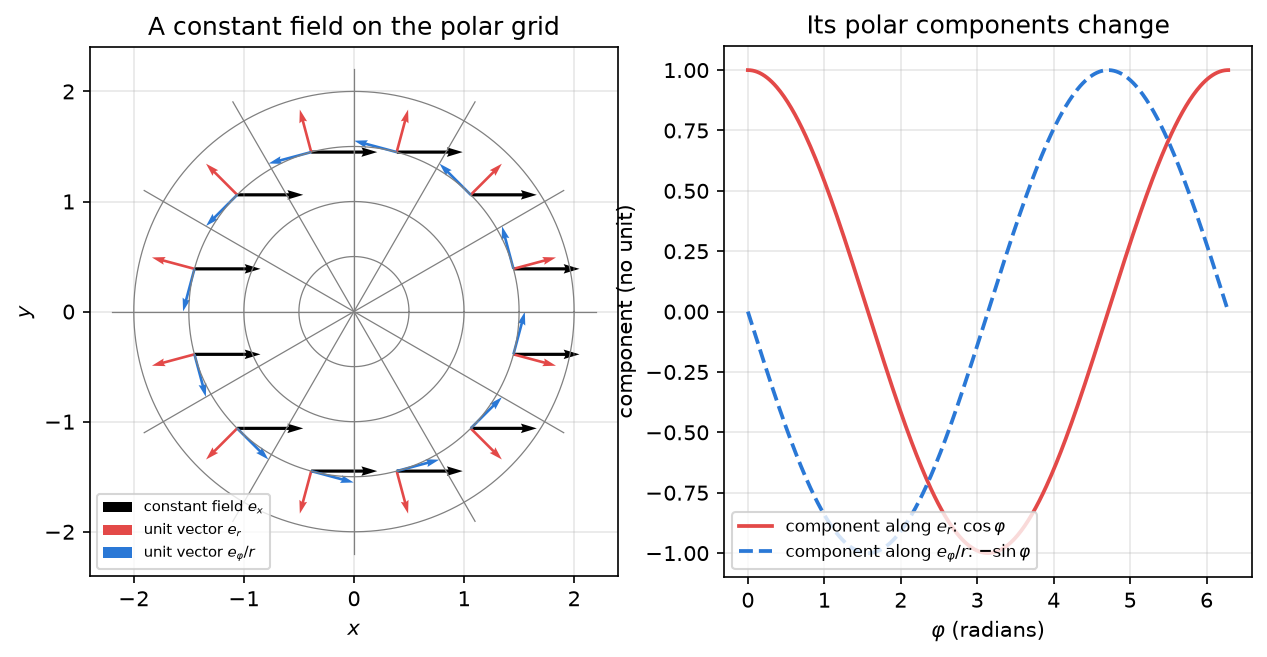

Figure 03c.1 saved as Revision/textbook/figures/03c_1_plane_polar_components.png
PASS the components of the unit field e_x have length 1 at every point


In [5]:
BLUE, ORANGE, AQUA, RED, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#4a3aa7"
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.6))
ax = axes[0]
angles = np.linspace(0.0, 2 * np.pi, 400)
for radius in (0.5, 1.0, 1.5, 2.0):  # circles of constant r
    ax.plot(radius * np.cos(angles), radius * np.sin(angles), color="grey", lw=0.6)
for ray in np.arange(12) * np.pi / 6:  # rays of constant phi
    ax.plot([0, 2.2 * np.cos(ray)], [0, 2.2 * np.sin(ray)], color="grey", lw=0.6)
points = np.arange(12) * np.pi / 6 + np.pi / 12  # the angles of the 12 points
px, py = 1.5 * np.cos(points), 1.5 * np.sin(points)
ax.quiver(px, py, np.ones(12), np.zeros(12), color="black", scale=8, width=0.006,
          label="constant field $e_x$")
ax.quiver(px, py, np.cos(points), np.sin(points), color=RED, scale=12,
          width=0.005, label="unit vector $e_r$")
ax.quiver(px, py, -np.sin(points), np.cos(points), color=BLUE, scale=12,
          width=0.005, label="unit vector $e_\\varphi / r$")
ax.set_aspect("equal")
ax.set_xlim(-2.4, 2.4)
ax.set_ylim(-2.4, 2.4)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("A constant field on the polar grid")
ax.legend(fontsize=7, loc="lower left")
ax = axes[1]
ax.plot(angles, np.cos(angles), color=RED, lw=1.8,
        label="component along $e_r$: $\\cos\\varphi$")
ax.plot(angles, -np.sin(angles), color=BLUE, lw=1.8, ls="--",
        label="component along $e_\\varphi/r$: $-\\sin\\varphi$")
ax.set_xlabel("$\\varphi$ (radians)")
ax.set_ylabel("component (no unit)")
ax.set_title("Its polar components change")
ax.legend(fontsize=8, loc="lower left")
save_figure(fig, "plane_polar_components",
            "The flat plane in polar coordinates. Left: the polar grid (grey circles "
            "of constant $r$ and rays of constant $\\varphi$), the constant vector "
            "field $e_x$ at twelve points on the circle $r = 1.5$ (black arrows, all "
            "equal), and the polar unit vectors $e_r$ (red) and $e_\\varphi/r$ "
            "(blue) at the same points, which turn with the angle; axes $x$ and $y$ "
            "(pure numbers). Right: the components of $e_x$ along $e_r$ "
            "($\\cos\\varphi$, solid) and along $e_\\varphi/r$ ($-\\sin\\varphi$, "
            "dashed) as functions of $\\varphi$ in radians. The components change "
            "although the field does not: the Christoffel symbols of the polar "
            "coordinates account for this change, while the Riemann tensor of the "
            "plane is zero.")
check(np.allclose(np.cos(points) ** 2 + np.sin(points) ** 2, 1.0),
      "the components of the unit field e_x have length 1 at every point")

## 7. The sphere of radius $a$

The point $(a\sin\theta\cos\varphi,\ a\sin\theta\sin\varphi,\ a\cos\theta)$ moves by
$a\, d\theta$ along a meridian and by $a\sin\theta\, d\varphi$ along a circle of
latitude, at right angles, so $ds^2 = a^2(d\theta^2 + \sin^2\theta\, d\varphi^2)$.
By hand, with $\partial_\theta(a^2\sin^2\theta) = 2a^2\sin\theta\cos\theta$:
$\Gamma^\theta{}_{\varphi\varphi} = -\sin\theta\cos\theta$ and
$\Gamma^\varphi{}_{\theta\varphi} = \cos\theta/\sin\theta = \cot\theta$. The next
cell computes these, the Riemann tensor, its Gaussian curvature
$R^{\theta\varphi}{}_{\theta\varphi}$, the Ricci tensor, the Ricci scalar and the
Kretschmann scalar, and checks $1/a^2$, $2/a^2$ and $4/a^4$.

In [6]:
theta = sp.symbols("theta", positive=True)
a = sp.symbols("a", positive=True)  # the radius of the sphere
sphere = sp.diag(a ** 2, a ** 2 * sp.sin(theta) ** 2)
ANGLES = [theta, phi]
ANGLE_NAMES = ["theta", "phi"]
sphere_gamma = christoffel(sphere, ANGLES)
for i, j, k in itertools.product(range(2), repeat=3):
    if sphere_gamma[i][j][k] != 0:
        say(f"  Gamma^{ANGLE_NAMES[i]}_({ANGLE_NAMES[j]} {ANGLE_NAMES[k]}) = "
            f"{sphere_gamma[i][j][k]}")
sphere_riemann = riemann(sphere_gamma, ANGLES)
sphere_mixed = raise_second(sphere_riemann, sphere)
for key, value in sorted(sphere_mixed.items()):
    say(f"  R^({ANGLE_NAMES[key[0]]} {ANGLE_NAMES[key[1]]})_"
        f"({ANGLE_NAMES[key[2]]} {ANGLE_NAMES[key[3]]}) = {value}")
sphere_ricci = ricci(sphere_mixed, 2)
sphere_R = sp.simplify(sphere_ricci.trace())
sphere_K = kretschmann(sphere_mixed)
say(f"Ricci tensor R^a_b = {sphere_ricci.tolist()}")
say(f"Ricci scalar R = {sphere_R},  Kretschmann scalar K = {sphere_K}")
check(sp.simplify(sphere_gamma[0][1][1] + sp.sin(theta) * sp.cos(theta)) == 0
      and sp.simplify(sphere_gamma[1][0][1] - sp.cot(theta)) == 0,
      "sphere: Gamma^theta_(phi phi) = -sin cos, Gamma^phi_(theta phi) = cot theta")
check(sphere_mixed[(0, 1, 0, 1)] == 1 / a ** 2,
      "the Gaussian curvature of the sphere is 1/a^2 at every point")
check(sphere_R == 2 / a ** 2 and sphere_K == 4 / a ** 4,
      "Ricci scalar 2/a^2 and Kretschmann scalar 4/a^4")

  Gamma^theta_(phi phi) = -sin(2*theta)/2
  Gamma^phi_(theta phi) = 1/tan(theta)
  Gamma^phi_(phi theta) = 1/tan(theta)
  R^(theta phi)_(theta phi) = a**(-2)
  R^(theta phi)_(phi theta) = -1/a**2
  R^(phi theta)_(theta phi) = -1/a**2
  R^(phi theta)_(phi theta) = a**(-2)
Ricci tensor R^a_b = [[a**(-2), 0], [0, a**(-2)]]
Ricci scalar R = 2/a**2,  Kretschmann scalar K = 4/a**4
PASS sphere: Gamma^theta_(phi phi) = -sin cos, Gamma^phi_(theta phi) = cot theta
PASS the Gaussian curvature of the sphere is 1/a^2 at every point
PASS Ricci scalar 2/a^2 and Kretschmann scalar 4/a^4


## 8. Parallel transport around a circle of latitude

Walk once around the circle of latitude $\theta = \theta_0$ (so $\varphi$ runs from
$0$ to $2\pi$ and $d\theta/d\varphi = 0$), carrying a vector without turning it. The
transport equation $dV^a/d\varphi + \sum_c \Gamma^a{}_{\varphi c} V^c = 0$ has only
two terms, one for each component:

$$\frac{dV^\theta}{d\varphi} = \sin\theta_0\cos\theta_0\, V^\varphi,\qquad
\frac{dV^\varphi}{d\varphi} = -\cot\theta_0\, V^\theta .$$

With the lengths $u = a V^\theta$ and $w = a\sin\theta_0\, V^\varphi$ along the unit
vectors $e_\theta$ (south) and $e_\varphi/(a \sin\theta_0)$ (east) this reads
$du/d\varphi = \cos\theta_0\, w$, $dw/d\varphi = -\cos\theta_0\, u$: the vector
turns relative to the local south-east frame at the constant rate $\cos\theta_0$.
After one round it has turned by $-2\pi\cos\theta_0$, which is the same direction as
a turn by $2\pi(1 - \cos\theta_0)$ (they differ by one whole turn). And
$2\pi a^2(1 - \cos\theta_0)$ is the area of the cap north of the circle: **the
turning angle is the enclosed area times the curvature $1/a^2$**. On the plane the
angle would be zero.

The next cell defines a general RK4 integrator and integrates the two equations
numerically with $a = 1$, starting with the unit vector pointing south
($u = 1$, $w = 0$), for $\theta_0 = \pi/3$; there $1 - \cos\theta_0 = 1/2$, so the
vector must come back pointing north, exactly reversed.

In [7]:
def rk4(f, y0, t0, t1, steps):
    """Solve dy/dt = f(t, y) from t0 to t1 with the classical Runge-Kutta method in
    steps equal steps; return the times and the states (one row per time)."""
    h = (t1 - t0) / steps
    times = t0 + h * np.arange(steps + 1)
    states = np.zeros((steps + 1, len(y0)))
    states[0] = y0
    for n in range(steps):
        t, y = times[n], states[n]
        k1 = f(t, y)
        k2 = f(t + h / 2, y + h / 2 * k1)
        k3 = f(t + h / 2, y + h / 2 * k2)
        k4 = f(t + h, y + h * k3)
        states[n + 1] = y + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return times, states


def transport(theta0, steps=2000):
    """Parallel transport of the unit south vector once around latitude theta0
    (a = 1): the components V^theta, V^phi as functions of phi."""
    def f(t, y):
        return np.array([np.sin(theta0) * np.cos(theta0) * y[1],
                         -np.cos(theta0) / np.sin(theta0) * y[0]])
    return rk4(f, np.array([1.0, 0.0]), 0.0, 2 * np.pi, steps)


def turning_angle(theta0):
    """The angle (0 to 2 pi) by which the vector comes back turned."""
    _, states = transport(theta0)
    u, w = states[-1, 0], np.sin(theta0) * states[-1, 1]  # lengths south, east
    return np.mod(np.arctan2(w, u), 2 * np.pi)


theta0 = np.pi / 3
phis, states = transport(theta0)
lengths = np.sqrt(states[:, 0] ** 2 + (np.sin(theta0) * states[:, 1]) ** 2)
say(f"start: V = {states[0].round(12).tolist()},  end: V = "
    f"{states[-1].round(12).tolist()}")
check(np.max(np.abs(lengths - 1.0)) < 1e-12,
      "parallel transport keeps the length of the vector")
check(np.max(np.abs(states[-1] - np.array([-1.0, 0.0]))) < 1e-10,
      "at theta0 = pi/3 the vector comes back exactly reversed")

start: V = [1.0, 0.0],  end: V = [-1.0, -0.0]
PASS parallel transport keeps the length of the vector
PASS at theta0 = pi/3 the vector comes back exactly reversed


The next cell draws the transport on the sphere: a wire model of the sphere, the
circle of latitude $\theta_0 = \pi/3$, and the transported vector at 16 points of
the circle. The arrow at $\varphi$ is $u\, e_\theta + w\, e_\varphi^{\rm unit}$ with
the 3-dimensional unit vectors $e_\theta = (\cos\theta\cos\varphi,\
\cos\theta\sin\varphi,\ -\sin\theta)$ and $e_\varphi^{\rm unit} = (-\sin\varphi,\
\cos\varphi,\ 0)$.

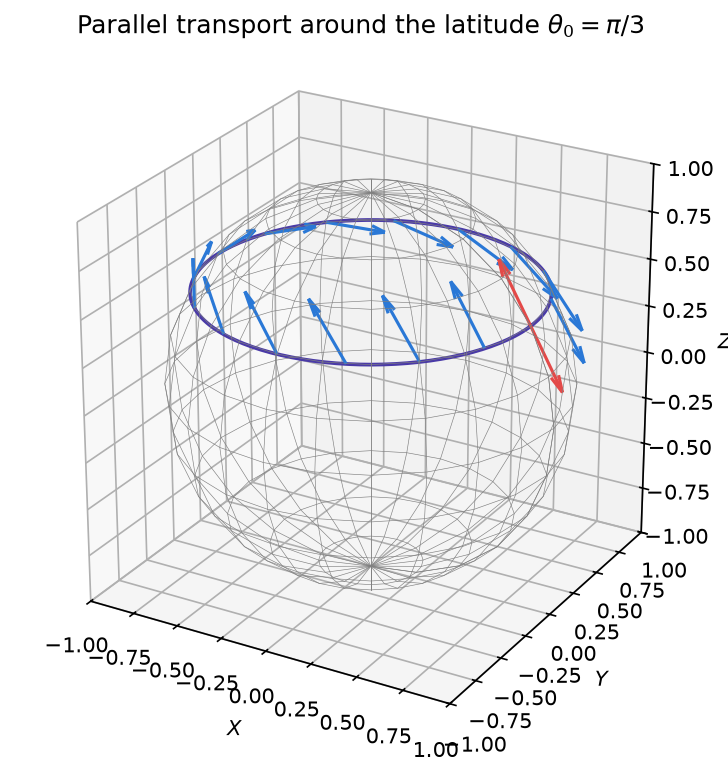

Figure 03c.2 saved as Revision/textbook/figures/03c_2_parallel_transport_sphere.png
PASS the turning angle at theta0 = pi/3 is pi


In [8]:
def point(th, ph):
    """The point of the unit sphere at the angles th, ph."""
    return np.array([np.sin(th) * np.cos(ph), np.sin(th) * np.sin(ph), np.cos(th)])


def wire_sphere(ax):
    """Draw a light wire model of the unit sphere into the 3-D axes ax."""
    th, ph = np.meshgrid(np.linspace(0, np.pi, 13), np.linspace(0, 2 * np.pi, 25))
    ax.plot_wireframe(np.sin(th) * np.cos(ph), np.sin(th) * np.sin(ph), np.cos(th),
                      color="grey", lw=0.3)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.view_init(elev=25, azim=-60)
    ax.set_xlabel("$X$")
    ax.set_ylabel("$Y$")
    ax.set_zlabel("$Z$")


fig = plt.figure(figsize=(6.4, 6.0))
ax = fig.add_subplot(projection="3d")
wire_sphere(ax)
circle = np.array([point(theta0, p) for p in np.linspace(0, 2 * np.pi, 200)])
ax.plot(circle[:, 0], circle[:, 1], circle[:, 2], color=VIOLET, lw=1.8)
for n in range(0, 2001, 125):  # 17 points, the last one equal to the first
    ph = phis[n]
    u, w = states[n, 0], np.sin(theta0) * states[n, 1]
    e_theta = np.array([np.cos(theta0) * np.cos(ph), np.cos(theta0) * np.sin(ph),
                        -np.sin(theta0)])
    e_phi = np.array([-np.sin(ph), np.cos(ph), 0.0])
    arrow = 0.35 * (u * e_theta + w * e_phi)
    start = point(theta0, ph)
    colour = RED if n in (0, 2000) else BLUE
    ax.quiver(*start, *arrow, color=colour, lw=1.5, arrow_length_ratio=0.25)
ax.set_title("Parallel transport around the latitude $\\theta_0 = \\pi/3$")
save_figure(fig, "parallel_transport_sphere",
            "Parallel transport on the unit sphere (wire model; axes $X$, $Y$, $Z$ "
            "in units of the radius $a = 1$): a vector that starts at "
            "$\\varphi = 0$ on the circle of latitude $\\theta_0 = \\pi/3$ (violet) "
            "pointing south is carried once around the circle without turning; the "
            "blue arrows show it at sixteen intermediate points, computed with RK4. "
            "Seen from the local south and east directions it turns steadily, and "
            "when it is back at the start (red arrow, drawn at both ends) it points "
            "north: it has turned by $\\pi$, the area $2\\pi(1 - \\cos\\theta_0) = "
            "\\pi$ of the cap above the circle divided by $a^2$.")
check(abs(turning_angle(theta0) - np.pi) < 1e-10,
      "the turning angle at theta0 = pi/3 is pi")

The next cell repeats the transport for 15 latitudes $\theta_0$ between $0.1$ and
$1.5$ and compares the measured turning angle with the area of the enclosed cap
divided by $a^2$, $2\pi(1 - \cos\theta_0)$. On the flat plane the turning angle of
every loop would be $0$ (the dotted line).

RESULT largest difference between the turning angle and area/a^2 = 5.0e-12 radians


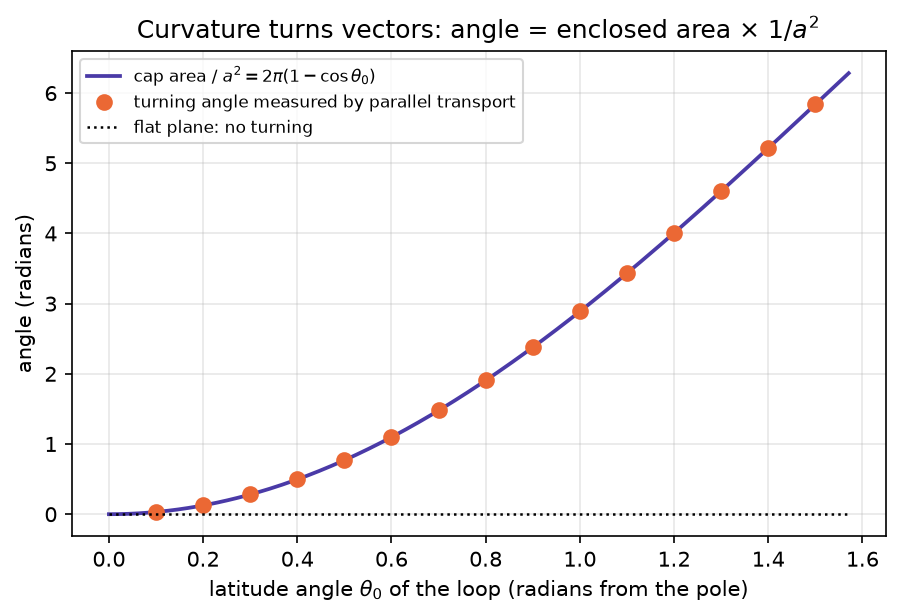

Figure 03c.3 saved as Revision/textbook/figures/03c_3_turning_angle.png
PASS the turning angle equals the enclosed area over a^2


In [9]:
latitudes = np.linspace(0.1, 1.5, 15)
measured = np.array([turning_angle(t0) for t0 in latitudes])
curve = np.linspace(0.0, np.pi / 2, 300)
fig, ax = plt.subplots()
ax.plot(curve, 2 * np.pi * (1 - np.cos(curve)), color=VIOLET, lw=1.8,
        label="cap area / $a^2 = 2\\pi(1 - \\cos\\theta_0)$")
ax.plot(latitudes, measured, "o", color=ORANGE, ms=7,
        label="turning angle measured by parallel transport")
ax.plot(curve, np.zeros_like(curve), ":", color="black", lw=1.2,
        label="flat plane: no turning")
ax.set_xlabel("latitude angle $\\theta_0$ of the loop (radians from the pole)")
ax.set_ylabel("angle (radians)")
ax.set_title("Curvature turns vectors: angle = enclosed area $\\times$ $1/a^2$")
ax.legend(fontsize=8)
deviation = np.max(np.abs(measured - 2 * np.pi * (1 - np.cos(latitudes))))
report("largest difference between the turning angle and area/a^2",
       f"{deviation:.1e}", "radians")
save_figure(fig, "turning_angle",
            "The turning angle of a vector carried once around a circle of latitude "
            "on a sphere of radius $a = 1$ (orange dots, computed by parallel "
            "transport with RK4 for 15 circles) and the area of the cap enclosed by "
            "the circle divided by $a^2$, $2\\pi(1 - \\cos\\theta_0)$ (violet line), "
            "against the angle $\\theta_0$ of the circle from the north pole in "
            "radians; vertical axis the angle in radians. The dots lie on the line: "
            "the turning angle equals the enclosed area times the Gaussian "
            "curvature $1/a^2$. On the flat plane (dotted line) a vector never "
            "turns.")
check(deviation < 1e-9, "the turning angle equals the enclosed area over a^2")

## 9. Geodesics are great circles

The geodesic equations of the sphere follow from its two Christoffel symbols
($s$ is the length along the curve, $a = 1$):

$$\frac{d^2\theta}{ds^2} = \sin\theta\cos\theta \Bigl(\frac{d\varphi}{ds}\Bigr)^2,
\qquad \frac{d^2\varphi}{ds^2} = -2\cot\theta\, \frac{d\theta}{ds}
\frac{d\varphi}{ds}.$$

(The factor 2 comes from the two equal terms $\Gamma^\varphi{}_{\theta\varphi}$ and
$\Gamma^\varphi{}_{\varphi\theta}$.) The next cell writes them as four first-order
equations for $(\theta, \varphi, d\theta/ds, d\varphi/ds)$, integrates three
geodesics with RK4 that leave the point $\theta = \pi/2$, $\varphi = 0$ on the
equator in three directions (at $20$, $50$ and $80$ degrees north of east), each for
the length $2\pi$ (once around), and checks that each stays in the plane through the
centre of the sphere spanned by its starting point and starting direction, which
means it is a great circle. It also checks that the circle of latitude
$\theta_0 = \pi/3$ is NOT a geodesic: along it $d^2\theta/ds^2 = 0$, but the
right-hand side $\sin\theta_0\cos\theta_0 (d\varphi/ds)^2$ is not zero.

In [10]:
def geodesic_rhs(s, y):
    """The geodesic equations of the unit sphere for y = (theta, phi, dtheta,
    dphi)."""
    th, ph, dth, dph = y
    return np.array([dth, dph, np.sin(th) * np.cos(th) * dph ** 2,
                     -2 * np.cos(th) / np.sin(th) * dth * dph])


geodesics = {}
for degrees in (20, 50, 80):
    alpha = np.radians(degrees)  # the direction, measured from east towards north
    # unit speed at the equator: dtheta/ds = -sin(alpha) (north), dphi/ds = cos(alpha)
    start = np.array([np.pi / 2, 0.0, -np.sin(alpha), np.cos(alpha)])
    _, path = rk4(geodesic_rhs, start, 0.0, 2 * np.pi, 4000)
    xyz = np.array([point(th, ph) for th, ph in path[:, :2]])
    # the starting direction in X, Y, Z: east is (0, 1, 0), north is (0, 0, 1)
    velocity0 = np.array([0.0, np.cos(alpha), np.sin(alpha)])
    normal = np.cross(xyz[0], velocity0)  # perpendicular to the expected plane
    geodesics[degrees] = (xyz, np.max(np.abs(xyz @ normal)))
    say(f"  direction {degrees:2d} degrees: largest distance from the plane "
        f"= {geodesics[degrees][1]:.1e}, end point back at start: "
        f"{np.allclose(xyz[-1], xyz[0], atol=1e-8)}")
check(all(distance < 1e-8 for _, distance in geodesics.values()),
      "the three geodesics stay in planes through the centre: great circles")
theta_circle = np.pi / 3
residual = np.sin(theta_circle) * np.cos(theta_circle) * (1 / np.sin(theta_circle)) ** 2
report("geodesic equation of the latitude theta0 = pi/3: missing acceleration",
       f"{residual:.6f}")
check(residual > 0.5, "the circle of latitude theta0 = pi/3 is not a geodesic")

  direction 20 degrees: largest distance from the plane = 1.2e-13, end point back at
    start: True
  direction 50 degrees: largest distance from the plane = 6.2e-13, end point back at
    start: True
  direction 80 degrees: largest distance from the plane = 7.1e-11, end point back at
    start: True
PASS the three geodesics stay in planes through the centre: great circles
RESULT geodesic equation of the latitude theta0 = pi/3: missing acceleration = 0.577350
PASS the circle of latitude theta0 = pi/3 is not a geodesic


The next cell draws the three geodesics and, for contrast, the circle of latitude
$\theta_0 = \pi/3$, on the wire model of the sphere.

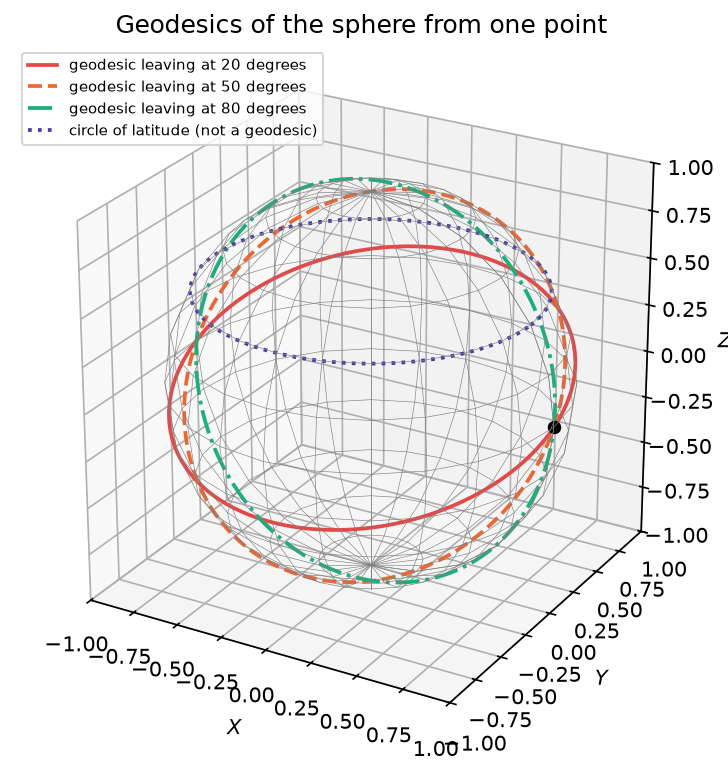

Figure 03c.4 saved as Revision/textbook/figures/03c_4_geodesics_sphere.png
PASS every geodesic returns to its start after the length 2 pi


In [11]:
fig = plt.figure(figsize=(6.4, 6.0))
ax = fig.add_subplot(projection="3d")
wire_sphere(ax)
for (degrees, (xyz, _)), colour, style in zip(geodesics.items(),
                                              (RED, ORANGE, AQUA), ("-", "--", "-.")):
    ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2], color=colour, ls=style, lw=1.8,
            label=f"geodesic leaving at {degrees} degrees")
ax.plot(circle[:, 0], circle[:, 1], circle[:, 2], color=VIOLET, ls=":", lw=1.8,
        label="circle of latitude (not a geodesic)")
ax.scatter([1.0], [0.0], [0.0], color="black", s=30)
ax.set_title("Geodesics of the sphere from one point")
ax.legend(fontsize=7, loc="upper left")
save_figure(fig, "geodesics_sphere",
            "Three geodesics of the unit sphere (axes $X$, $Y$, $Z$ in units of the "
            "radius), computed with RK4 from the geodesic equations, leaving the "
            "point $(1, 0, 0)$ on the equator (black dot) at $20$, $50$ and $80$ "
            "degrees north of east (solid, dashed and dash-dotted); each is a great "
            "circle, a circle whose centre is the centre of the sphere, and comes "
            "back to its start after the length $2\\pi a$. The dotted circle of "
            "latitude $\\theta_0 = \\pi/3$ is not a geodesic: a traveller who follows "
            "it must keep turning towards the pole.")
check(all(np.allclose(xyz[-1], xyz[0], atol=1e-8) for xyz, _ in geodesics.values()),
      "every geodesic returns to its start after the length 2 pi")

## 10. Initially parallel geodesics meet

Two meridians cross the equator at right angles, so they start parallel; on a
plane they would stay at the same distance for ever. On the sphere their distance,
measured along the circle of latitude, is $a\sin\theta\,\Delta\varphi =
a\cos(s/a)\,\Delta\varphi$ after the length $s$ ($\theta = \pi/2 - s/a$): they
approach each other and meet at the pole, $s = \pi a/2$. In general the distance
$\xi(s)$ between two neighbouring geodesics obeys the **geodesic deviation
equation** $d^2\xi/ds^2 = -\kappa\,\xi$ with the Gaussian curvature $\kappa =
R^{\theta\varphi}{}_{\theta\varphi} = 1/a^2$ computed in section 7. The next cell
solves this equation with RK4 from $\xi = 1$, $d\xi/ds = 0$ (in units of the starting
distance, $a = 1$), compares it with the exact distance of two meridians
$\Delta\varphi = 10^{-3}$ apart (the length of the straight chord between them,
divided by its starting value), and draws both together with the flat plane.

RESULT largest difference between the meridians and the deviation equation = 8.0e-14


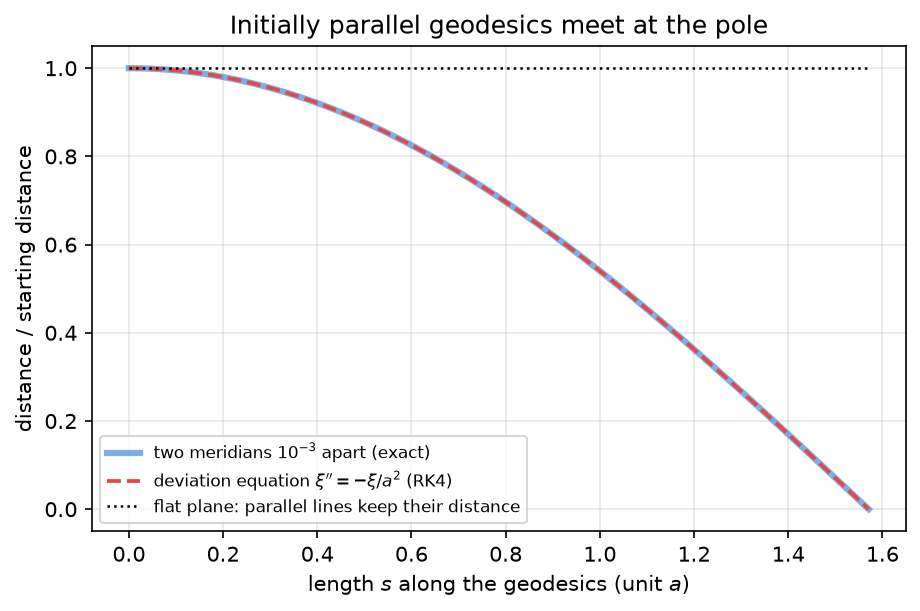

Figure 03c.5 saved as Revision/textbook/figures/03c_5_geodesic_deviation.png
PASS the curvature 1/a^2 predicts how fast neighbouring geodesics approach


In [12]:
kappa = float(sphere_mixed[(0, 1, 0, 1)].subs(a, 1))  # the Gaussian curvature, a = 1
s_values, deviation_states = rk4(lambda s, y: np.array([y[1], -kappa * y[0]]),
                                 np.array([1.0, 0.0]), 0.0, np.pi / 2, 1000)
d_phi = 1e-3  # the angle between the two meridians
chord = np.array([np.linalg.norm(point(np.pi / 2 - s, 0.0) - point(np.pi / 2 - s, d_phi))
                  for s in s_values]) / np.linalg.norm(point(np.pi / 2, 0.0)
                                                       - point(np.pi / 2, d_phi))
fig, ax = plt.subplots()
ax.plot(s_values, chord, color=BLUE, lw=3.0, alpha=0.6,
        label="two meridians $10^{-3}$ apart (exact)")
ax.plot(s_values, deviation_states[:, 0], "--", color=RED, lw=1.8,
        label="deviation equation $\\xi^{\\prime\\prime} = -\\xi/a^2$ (RK4)")
ax.plot(s_values, np.ones_like(s_values), ":", color="black", lw=1.2,
        label="flat plane: parallel lines keep their distance")
ax.set_xlabel("length $s$ along the geodesics (unit $a$)")
ax.set_ylabel("distance / starting distance")
ax.set_title("Initially parallel geodesics meet at the pole")
ax.legend(fontsize=8)
agreement = np.max(np.abs(chord - deviation_states[:, 0]))
report("largest difference between the meridians and the deviation equation",
       f"{agreement:.1e}")
save_figure(fig, "geodesic_deviation",
            "The distance between two neighbouring geodesics that start parallel, "
            "divided by its starting value, against the length $s$ travelled along "
            "them in units of the radius $a$: two meridians of the unit sphere "
            "$\\Delta\\varphi = 10^{-3}$ apart that leave the equator northwards "
            "(thick blue line, exact), the solution of the geodesic deviation "
            "equation $\\xi^{\\prime\\prime} = -\\kappa\\,\\xi$ with the Gaussian "
            "curvature $\\kappa = 1/a^2$ computed from the Riemann tensor (dashed "
            "red, RK4), and the flat plane (dotted). On the sphere the distance "
            "shrinks like $\\cos(s/a)$ and becomes zero at the pole, "
            "$s = \\pi a/2$; on the plane it stays constant.")
check(agreement < 1e-6,
      "the curvature 1/a^2 predicts how fast neighbouring geodesics approach")

## 11. The last check

The last cell checks that the five figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [13]:
figure_names = ["plane_polar_components", "parallel_transport_sphere",
                "turning_angle", "geodesics_sphere", "geodesic_deviation"]
files = [output_file(f"{FIGURE_FOLDER}/03c_{k}_{n}.png")
         for k, n in enumerate(figure_names, 1)]
check(all(path.is_file() for path in files), "all five figure files exist")
all_checks_passed()

PASS all five figure files exist
ALL 16 CHECKS PASSED (notebook 03c)


## 12. What this notebook showed

- The flat plane in polar coordinates has the non-zero Christoffel symbols
  $\Gamma^r{}_{\varphi\varphi} = -r$ and $\Gamma^\varphi{}_{r\varphi} = 1/r$, but its
  Riemann tensor is zero: Christoffel symbols belong to the coordinates, curvature to
  the space. The constant field $e_x$ has changing polar components and zero
  covariant derivative.
- The sphere of radius $a$ has the Gaussian curvature
  $R^{\theta\varphi}{}_{\theta\varphi} = 1/a^2$ at every point, the Ricci scalar
  $2/a^2$ and the Kretschmann scalar $4/a^4$ (exact, with sympy).
- Parallel transport around a circle of latitude turns a vector by the enclosed area
  divided by $a^2$ (numerically, RK4, to better than $10^{-9}$); at
  $\theta_0 = \pi/3$ the vector comes back reversed. Its length never changes.
- The geodesics of the sphere are great circles; a circle of latitude other than
  the equator is not a geodesic.
- Geodesics that start parallel approach each other as the geodesic deviation
  equation with the curvature $1/a^2$ predicts, and meet at the pole.
- These are the same formulas and the same code that Notebook 03b applies to the
  author's 8-dimensional metric, where they give the curvature of the primordial
  gravitational field.